# AUGVIS

run on [kaggle](https://www.kaggle.com/code/aliaagheis/01-smoke-check-aguvis) or colab 

In [1]:
!pip install qwen-vl-utils
!git clone https://github.com/xlang-ai/aguvis

%cd aguvis
!hf download xlangai/Aguvis-7B-720P --local-dir ./models/aguvis-7B-720P
!curl -L -o onenote.png "https://raw.githubusercontent.com/YaraHisham61/Click2Act/exp-models-benchmarks/imgs/onenote.png"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 57.9 MB/s eta 0:00:00:00:0100:01
Cloning into 'aguvis'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 74 (delta 30), reused 52 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 192.97 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/kaggle/working/aguvis
A new version of huggingface_hub (1.10.1) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

Fetching 16 files: 100%|████████████████████████| 16/16 [02:07<00:00,  7.97s/it]
Download complete: : 16.6GB [02:07, 96.6MB/s]              /kaggle/working/aguvis/models/aguvis-7B-720P
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  118k  100  118k    0     0   634k      0 --:--:-- --:--:-- --:--:--  63

In [5]:
import torch
from PIL import Image
import numpy as np
from qwen_vl_utils import process_vision_info
from transformers import Qwen2VLForConditionalGeneration, Qwen2VLProcessor

from src.aguvis.constants import agent_system_message, chat_template, grounding_system_message, until, user_instruction

In [3]:
model_path = './models/aguvis-7B-720P'
device = 'cuda'
C2A_PALETTE = {
    "primary"   : "#2E86AB",
    "secondary" : "#A23B72",
    "tertiary"  : "#F18F01",
    "neutral"   : "#6C757D",
    "success"   : "#3BB273",
    "warning"   : "#E84855",
    "bg"        : "#F8F9FA",
    "text"      : "#212529",
}
temperature: float = 0
max_new_tokens: int = 1024

In [6]:
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_path,
    torch_dtype=torch.float16,      # Use fp16 to halve memory usage
    device_map="auto"               # Automatically splits across both T4s
)

processor = Qwen2VLProcessor.from_pretrained(model_path)
tokenizer = processor.tokenizer

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [7]:
image_path = 'onenote.png'
image = Image.open(image_path)
image_rgb = image.convert('RGB')
image_np = np.array(image_rgb)
w, h = image_rgb.size
print('image size:', w, h)

image size: 1919 1079


In [8]:
system_message = {
    "role": "system",
    "content": grounding_system_message,
}

user_message = {
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text": user_instruction.format(
                overall_goal="create new page",
                previous_actions="None  ",
                low_level_instruction="",
            ),
        }
    ],
}

recipient_text = "<|im_start|>assistant<|recipient|>os\n"

messages = [system_message, user_message]
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=False, chat_template=chat_template
)
text += recipient_text

In [9]:
print(text)

<|im_start|>system
You are a GUI agent. You are given a task and a screenshot of the screen. You need to perform a series of pyautogui actions to complete the task.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Please generate the next move according to the ui screenshot, instruction and previous actions.

Instruction: create new page

Previous actions:
None  
<|im_end|>
<|im_start|>assistant<|recipient|>os



In [10]:
image_inputs, video_inputs = process_vision_info(messages)

In [11]:
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")

In [12]:
inputs

{'input_ids': tensor([[151644,   8948,    198,  ..., 151657,    436,    198]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]]), 'pixel_values': tensor([[ 0.5873,  0.4559,  0.4559,  ...,  1.1647,  1.8046,  1.3780],
        [ 0.3975,  0.3975,  0.3975,  ...,  0.9799,  0.9656,  0.9656],
        [ 0.4413,  0.1201,  0.1493,  ...,  1.9468,  1.9468,  1.9468],
        ...,
        [-1.2229, -1.2229, -1.2229,  ..., -0.9683, -0.9825, -0.9967],
        [-1.2375, -1.2229, -1.2375,  ..., -0.9967, -0.9967, -0.9967],
        [-1.0039, -1.2521, -1.2229,  ..., -0.9967, -0.9967, -1.0252]]), 'image_grid_thw': tensor([[ 1, 52, 92]])}

In [13]:
inputs = inputs.to(model.device)
cont = model.generate(**inputs, temperature=temperature, max_new_tokens=max_new_tokens)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


In [15]:
cont

tensor([[151644,   8948,    198,  ...,     20,      8, 151658]],
       device='cuda:0')

In [16]:
cont_toks = cont.tolist()[0][len(inputs.input_ids[0]) :]
text_outputs = tokenizer.decode(cont_toks, skip_special_tokens=True).strip()

In [17]:
text_outputs

'pyautogui.click(x=0.131, y=0.9335)'

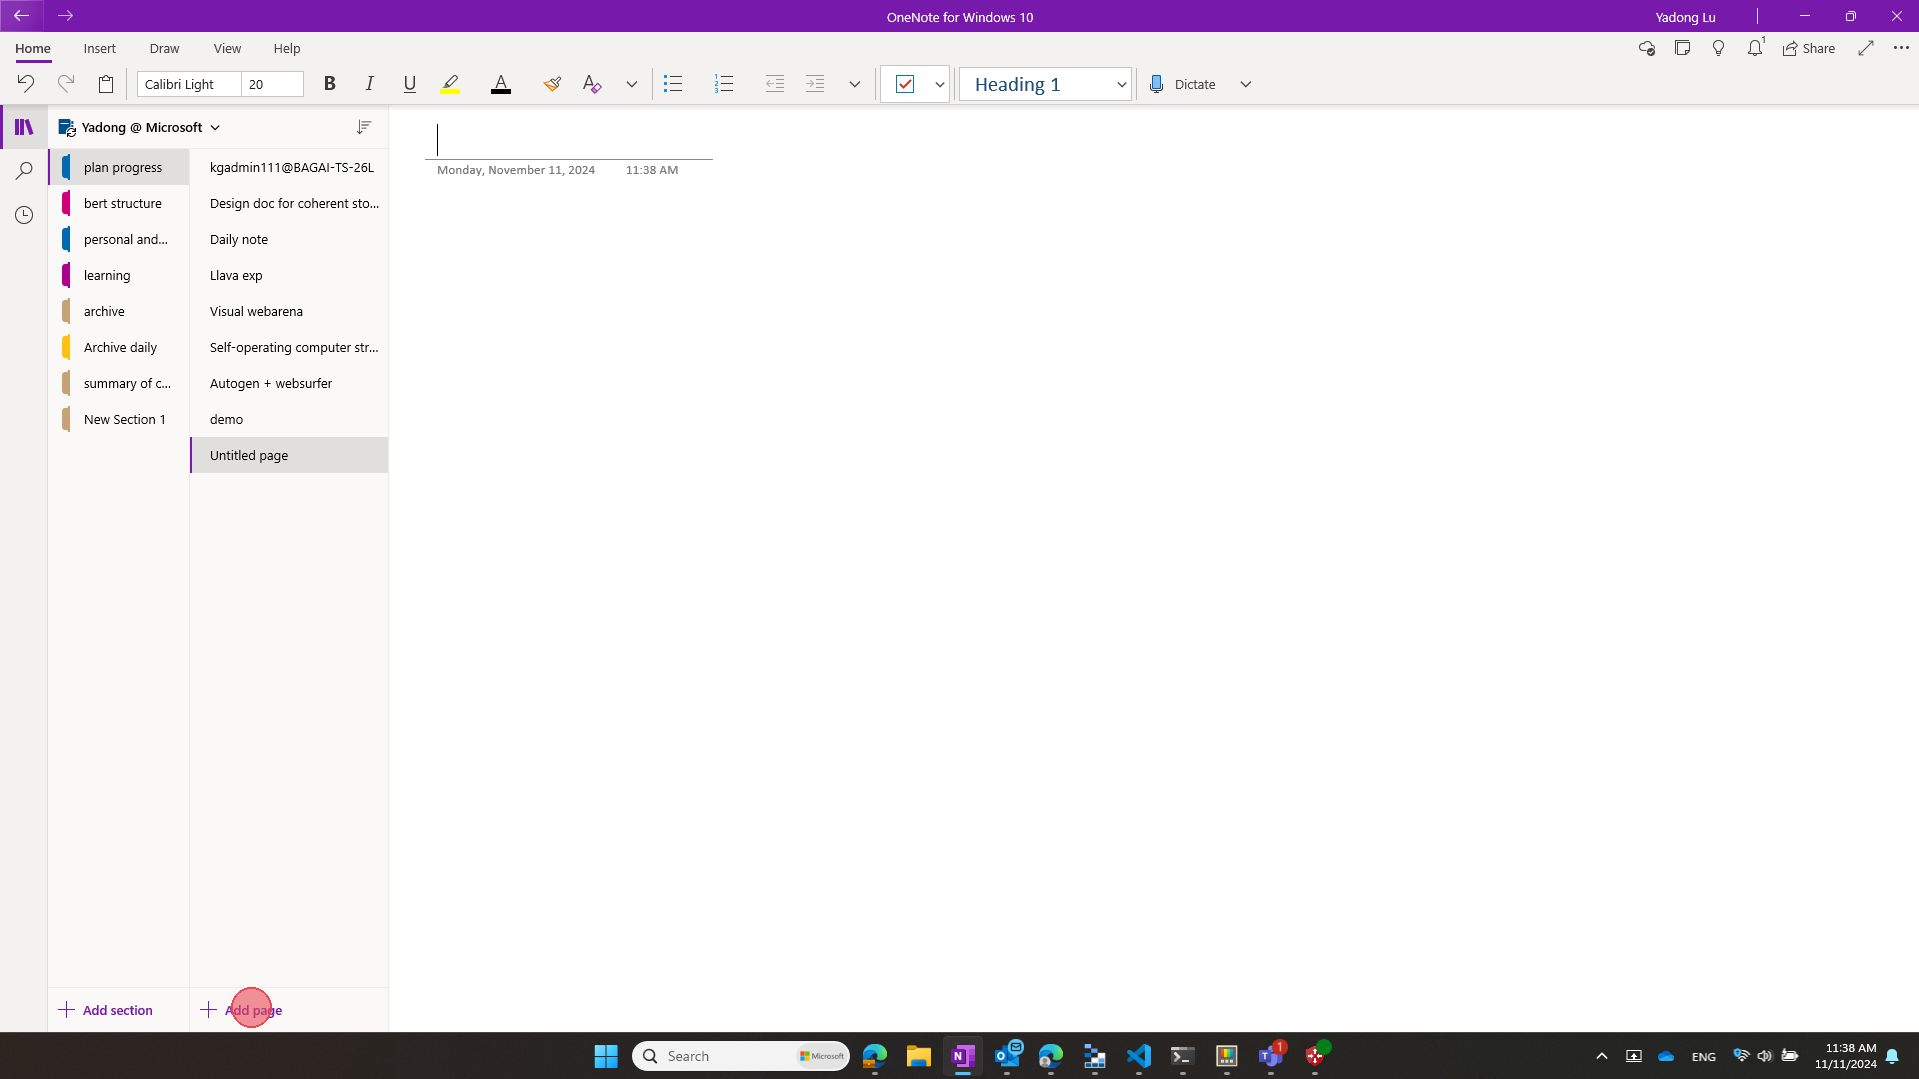

In [19]:
draw_click(image_rgb, 0.131*w, 0.9335*h)

In [18]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import numpy as np

def draw_click(image, x: int, y: int, radius: int = 20, opacity: float = 0.6,
               color: str = None):
    """Overlay a semi-transparent circle on an image to mark a click point.

    Args:
        image   : PIL.Image or numpy array (H, W, 3).
        x, y    : pixel coordinates of the circle centre.
        radius  : circle radius in pixels.
        opacity : alpha in [0, 1] — 0 = invisible, 1 = fully opaque.
        color   : hex colour string (default: C2A_PALETTE["warning"]).
        figsize : matplotlib figure size (used only when ax is None).
        ax      : existing Axes to draw on, or None for a standalone figure.
    """
    if color is None:
        color = C2A_PALETTE["warning"]

    # --- normalise to PIL RGB ---
    if isinstance(image, np.ndarray):
        pil_img = Image.fromarray(image.astype(np.uint8)).convert("RGB")
    else:
        pil_img = image.convert("RGB")

    # --- parse hex colour to RGB tuple ---
    hex_color = color.lstrip("#")
    rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

    # --- draw circle on a transparent overlay ---
    overlay = Image.new("RGBA", pil_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay)
    alpha = int(opacity * 255)
    bbox = [x - radius, y - radius, x + radius, y + radius]
    draw.ellipse(bbox, fill=(*rgb, alpha), outline=(*rgb, 255), width=2)

    # --- composite onto the original ---
    result = Image.alpha_composite(pil_img.convert("RGBA"), overlay).convert("RGB")
    

    return result


# Sample 2

In [21]:
system_message = {
    "role": "system",
    "content": grounding_system_message,
}

user_message = {
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text": user_instruction.format(
                overall_goal=task,
                previous_actions="None  ",
                low_level_instruction="",
            ),
        }
    ],
}

recipient_text = "<|im_start|>assistant<|recipient|>os\n"

messages = [system_message, user_message]
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=False, chat_template=chat_template
)
text += recipient_text


image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")

inputs = inputs.to(model.device)
cont = model.generate(**inputs, temperature=temperature, max_new_tokens=max_new_tokens)
cont_toks = cont.tolist()[0][len(inputs.input_ids[0]) :]
text_outputs = tokenizer.decode(cont_toks, skip_special_tokens=True).strip()

Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


In [22]:
text_outputs

'pyautogui.click(x=0.138, y=0.0785)'

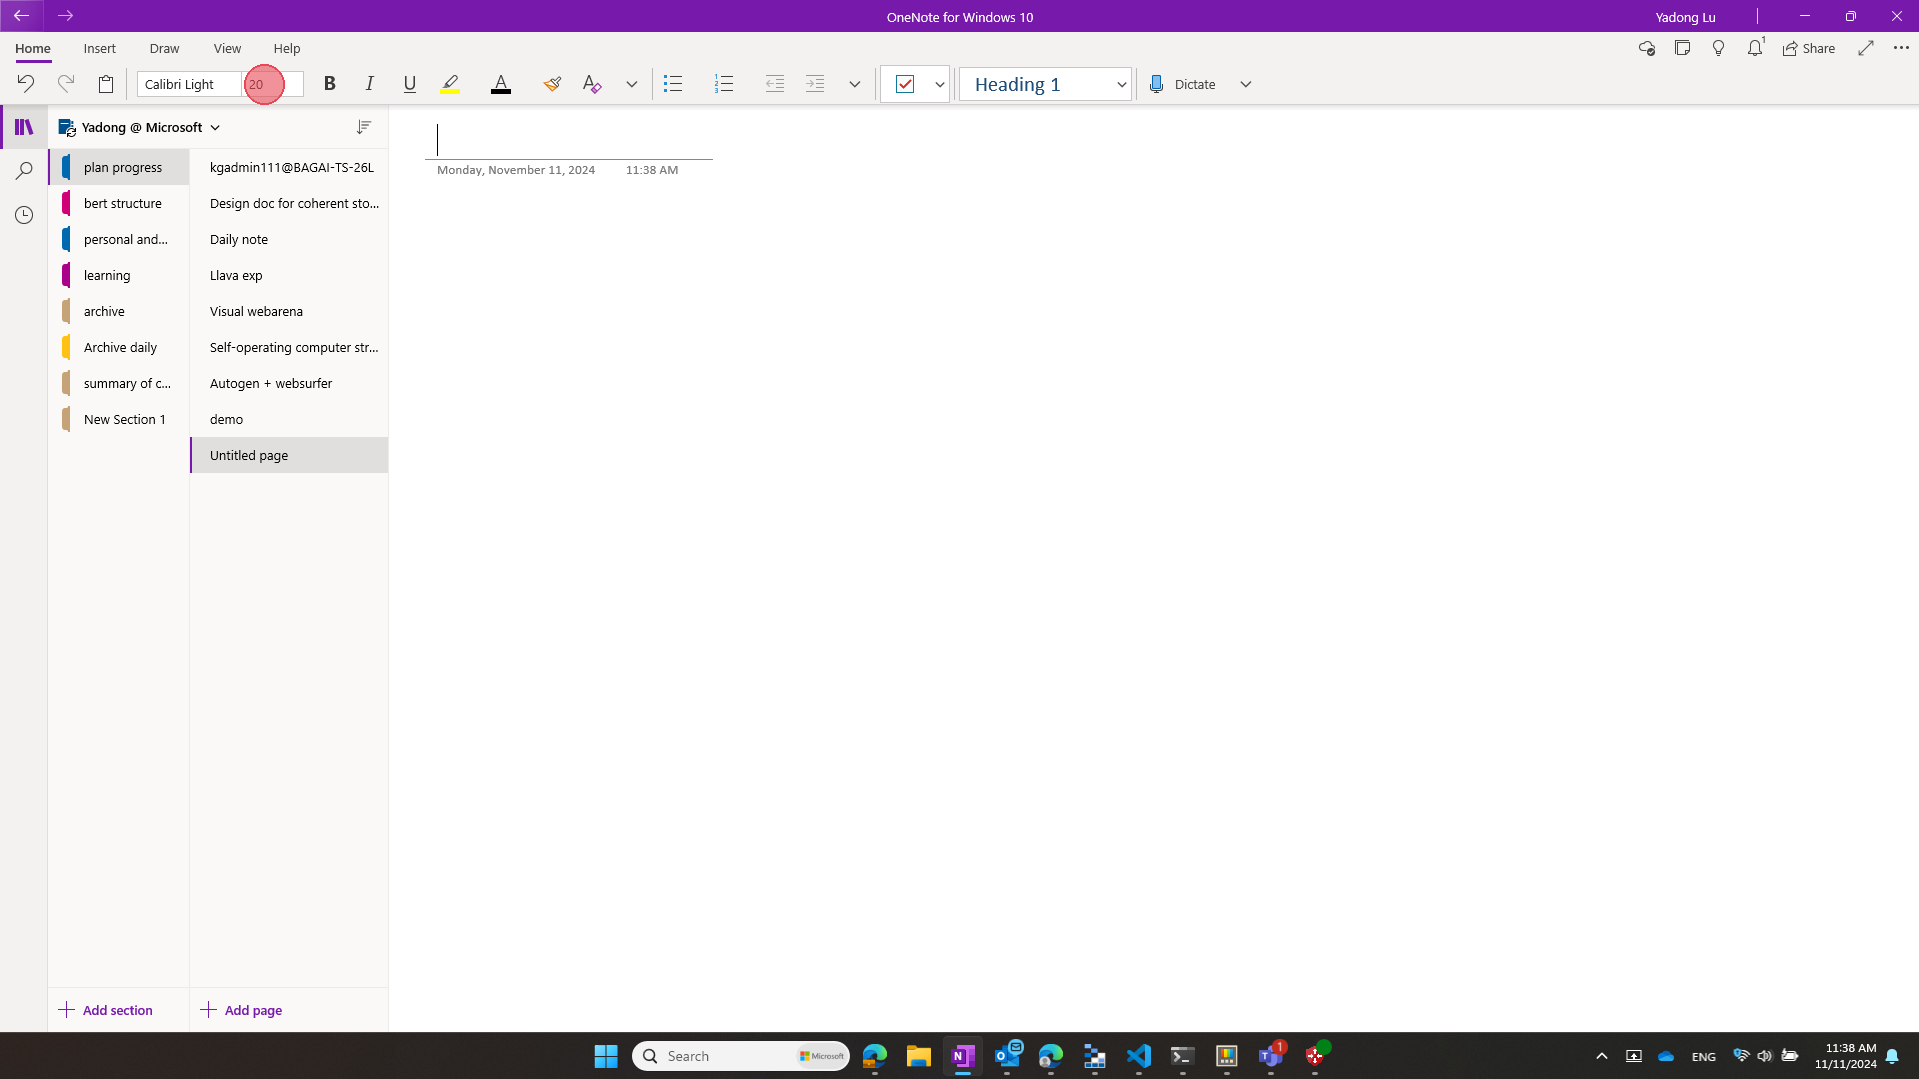

In [23]:
draw_click(image_rgb, 0.138*w, 0.0785*h)

# Sample 3

In [28]:
task = "save notebook to the cloud"

In [29]:
system_message = {
    "role": "system",
    "content": grounding_system_message,
}

user_message = {
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text": user_instruction.format(
                overall_goal=task,
                previous_actions="None  ",
                low_level_instruction="",
            ),
        }
    ],
}

recipient_text = "<|im_start|>assistant<|recipient|>os\n"

messages = [system_message, user_message]
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=False, chat_template=chat_template
)
text += recipient_text


image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")

inputs = inputs.to(model.device)
cont = model.generate(**inputs, temperature=temperature, max_new_tokens=max_new_tokens)
cont_toks = cont.tolist()[0][len(inputs.input_ids[0]) :]
text_outputs = tokenizer.decode(cont_toks, skip_special_tokens=True).strip()

Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


In [30]:
text_outputs

'pyautogui.click(x=0.864, y=0.0445)'

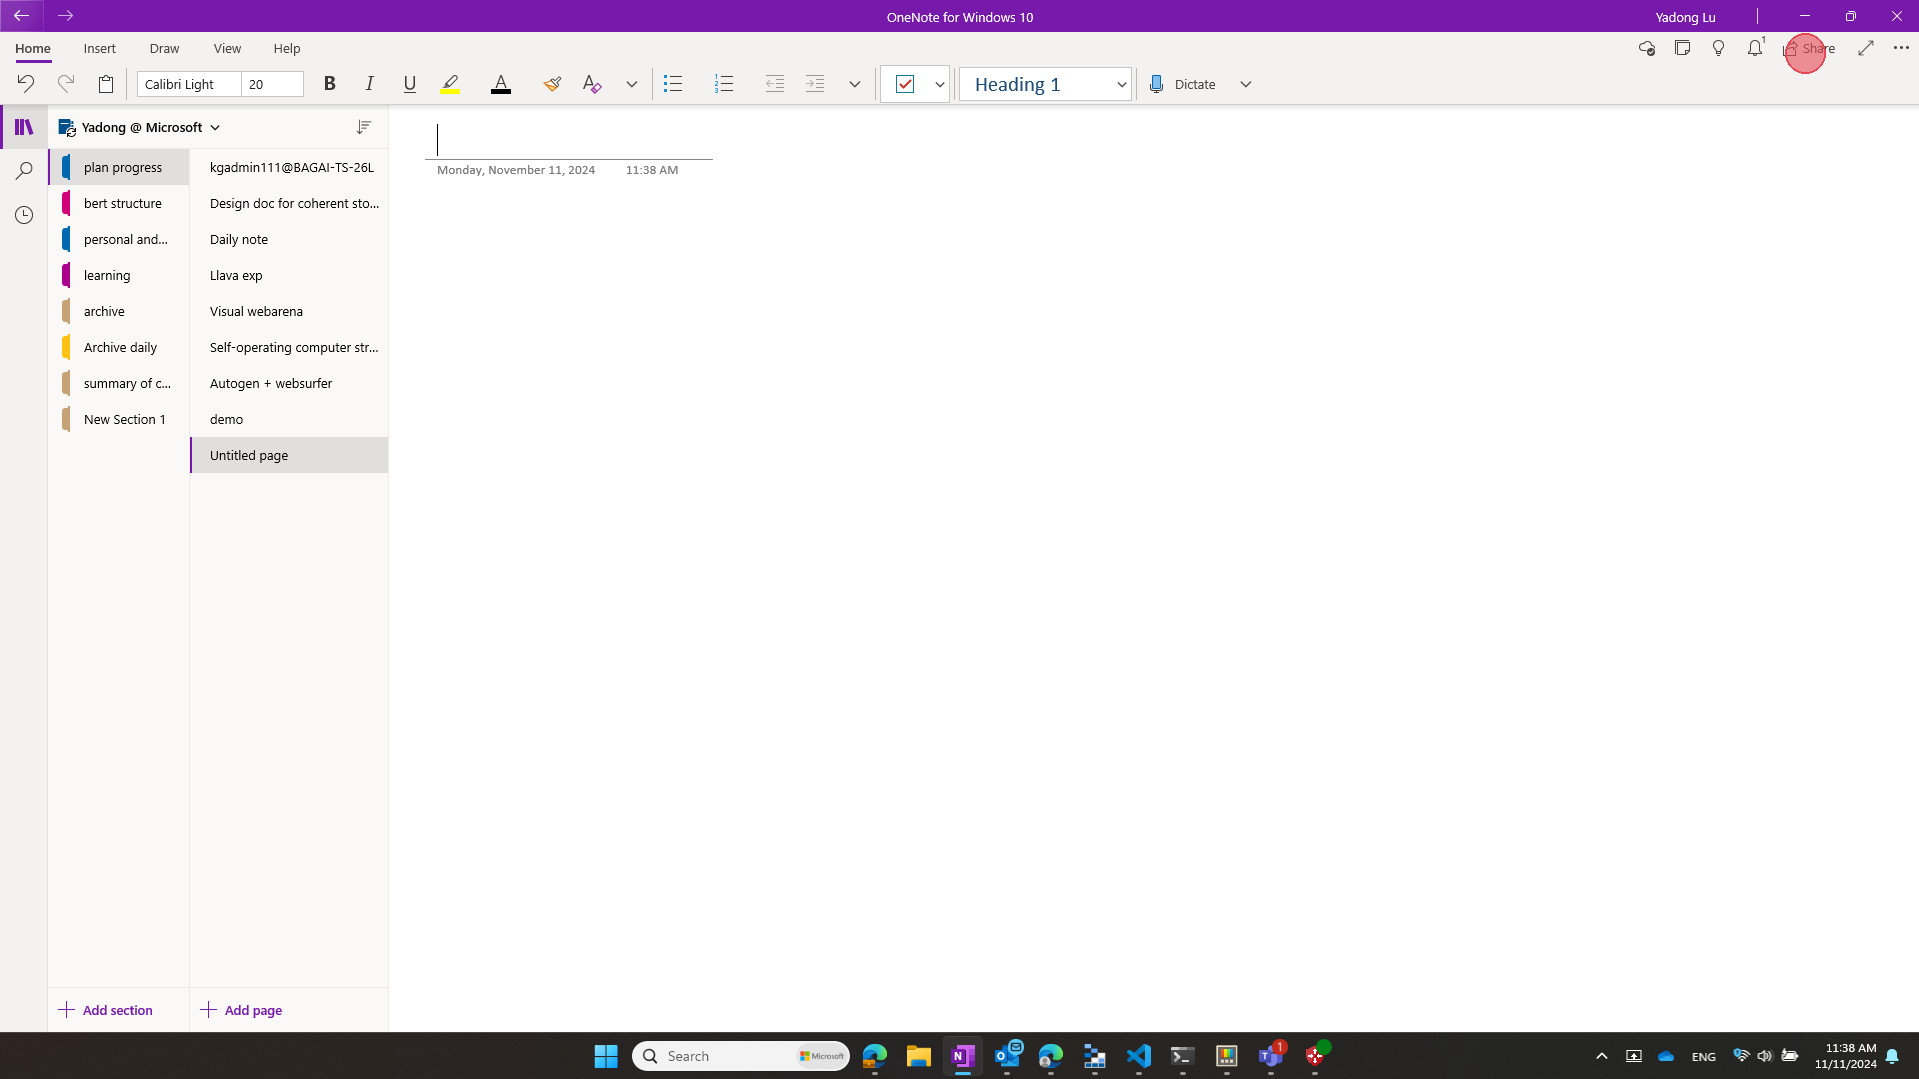

In [27]:
draw_click(image_rgb, 0.941*w, 0.0495*h)

# Sample 4

In [35]:
task = "select text highlighter"

In [36]:
system_message = {
    "role": "system",
    "content": grounding_system_message,
}

user_message = {
    "role": "user",
    "content": [
        {"type": "image", "image": image_rgb},
        {
            "type": "text",
            "text": user_instruction.format(
                overall_goal=task,
                previous_actions="None  ",
                low_level_instruction="",
            ),
        }
    ],
}

recipient_text = "<|im_start|>assistant<|recipient|>os\n"

messages = [system_message, user_message]
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=False, chat_template=chat_template
)
text += recipient_text


image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")

inputs = inputs.to(model.device)
cont = model.generate(**inputs, temperature=temperature, max_new_tokens=max_new_tokens)
cont_toks = cont.tolist()[0][len(inputs.input_ids[0]) :]
text_outputs = tokenizer.decode(cont_toks, skip_special_tokens=True).strip()

Setting `pad_token_id` to `eos_token_id`:151658 for open-end generation.


In [37]:
text_outputs

'pyautogui.click(x=0.231, y=0.0785)'

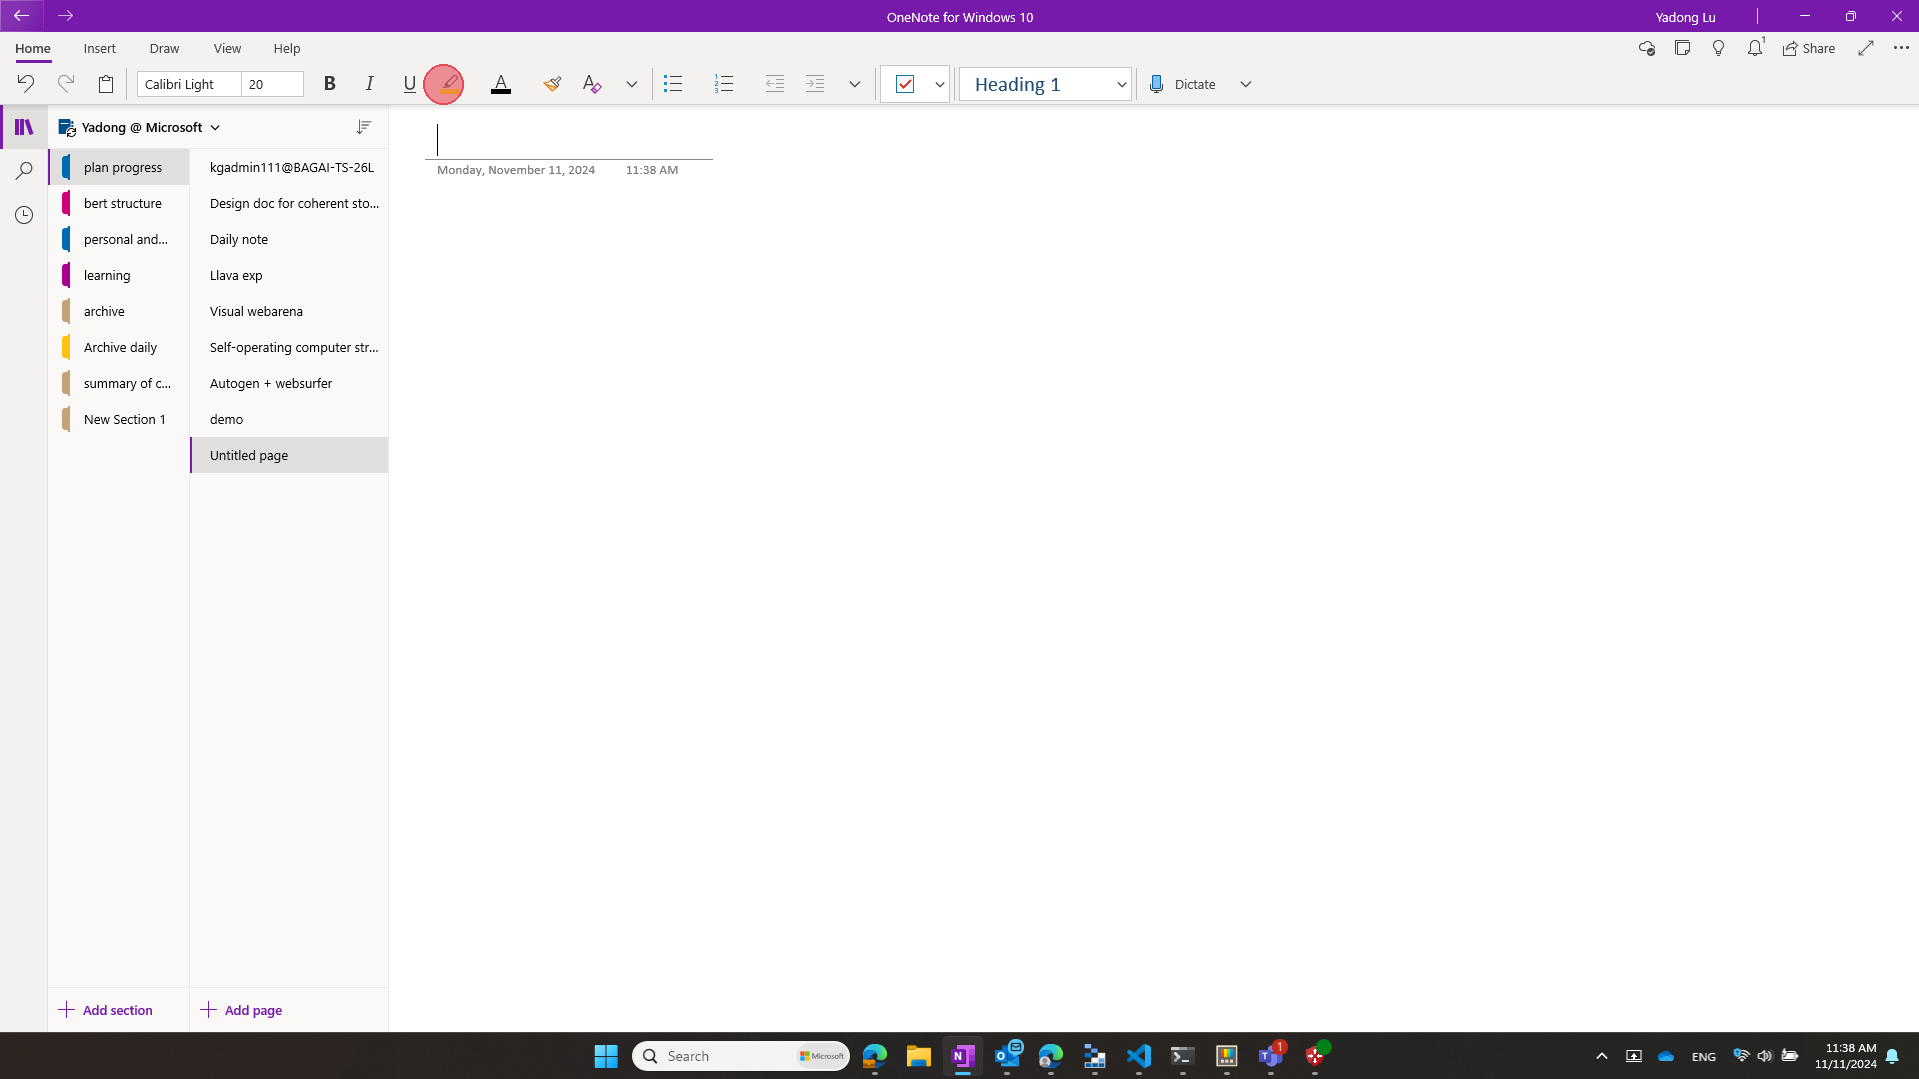

In [39]:
draw_click(image_rgb, 0.231*w, 0.0785*h)